# Dubai Real Estate Price Predictor
## Notebook 2: Feature Engineering, Model Training & Evaluation
**Author:** Vikas Varma Mudunuru  
**Input:** `transactions_cleaned.csv` (output from Notebook 01)  
**Goal:** Engineer features, train 4 models, compare performance, save best model.

## 1. Setup & Load Cleaned Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import joblib
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

# Load cleaned data
df = pd.read_csv('transactions_cleaned.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded: 1,153,228 rows, 51 columns


## 2. Feature Engineering

In [15]:
# --- Select and prepare features ---

# Categorical columns we want to encode
cat_cols = ['area_name_en', 'property_type_en', 'property_sub_type_en',
            'property_usage_en', 'rooms_en', 'nearest_metro_en']

# Numeric columns
num_cols = ['procedure_area', 'has_parking', 'is_offplan',
            'year', 'month', 'quarter']

# Target
target = 'actual_worth'

# Fill nulls in categorical columns
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill nulls in numeric columns
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print('Nulls filled.')

Nulls filled.


In [16]:
# --- Target Encoding for categorical columns ---
# Target encoding: replace category with mean price of that category
# Much better than one-hot for high-cardinality columns like area_name

encoded_cols = []
global_mean = df[target].mean()

for col in cat_cols:
    if col in df.columns:
        means = df.groupby(col)[target].mean()
        new_col = f'{col}_encoded'
        df[new_col] = df[col].map(means).fillna(global_mean)
        encoded_cols.append(new_col)
        print(f'Target encoded: {col} → {new_col} ({df[col].nunique()} unique values)')

Target encoded: area_name_en → area_name_en_encoded (236 unique values)
Target encoded: property_type_en → property_type_en_encoded (4 unique values)
Target encoded: property_sub_type_en → property_sub_type_en_encoded (19 unique values)
Target encoded: property_usage_en → property_usage_en_encoded (11 unique values)
Target encoded: rooms_en → rooms_en_encoded (16 unique values)
Target encoded: nearest_metro_en → nearest_metro_en_encoded (57 unique values)


In [17]:
# --- Final feature list ---
feature_cols = num_cols + encoded_cols

# Keep only columns that exist in df
feature_cols = [c for c in feature_cols if c in df.columns]

print(f'Total features: {len(feature_cols)}')
print('Features:', feature_cols)

Total features: 12
Features: ['procedure_area', 'has_parking', 'is_offplan', 'year', 'month', 'quarter', 'area_name_en_encoded', 'property_type_en_encoded', 'property_sub_type_en_encoded', 'property_usage_en_encoded', 'rooms_en_encoded', 'nearest_metro_en_encoded']


In [18]:
# --- Log transform the target (reduces skew, improves model performance) ---
df['log_price'] = np.log1p(df[target])

print('Target variable stats:')
print(f'  Original mean:     AED {df[target].mean():>12,.0f}')
print(f'  Log-transformed mean: {df["log_price"].mean():.4f}')

Target variable stats:
  Original mean:     AED    2,121,227
  Log-transformed mean: 14.1543


## 3. Train / Test Split

In [19]:
# Time-aware split: train on pre-2024, test on 2024+
# This is more realistic than random split — prevents data leakage
train_df = df[df['year'] < 2024].copy()
test_df  = df[df['year'] >= 2024].copy()

# If not enough test data, fall back to random 80/20
if len(test_df) < 1000:
    print('Not enough 2024+ data — using random 80/20 split instead')
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df['log_price']
y_test  = test_df['log_price']

# Keep original prices for MAE/RMSE reporting in AED
y_train_orig = train_df[target]
y_test_orig  = test_df[target]

print(f'Training set:  {len(X_train):>8,} rows')
print(f'Test set:      {len(X_test):>8,} rows')
print(f'Features:      {len(feature_cols)}')

Training set:   835,360 rows
Test set:       317,868 rows
Features:      12


## 4. Train All Models

In [20]:
# Helper function to evaluate a model and return metrics
def evaluate_model(name, model, X_train, X_test, y_train, y_test, y_test_orig):
    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)
    preds_aed = np.expm1(preds_log)  # reverse the log transform

    r2   = r2_score(y_test, preds_log)
    mae  = mean_absolute_error(y_test_orig, preds_aed)
    rmse = np.sqrt(mean_squared_error(y_test_orig, preds_aed))

    print(f'{name:<25} R²: {r2:.4f}  |  MAE: AED {mae:>12,.0f}  |  RMSE: AED {rmse:>12,.0f}')
    return {'name': name, 'model': model, 'r2': r2, 'mae': mae, 'rmse': rmse, 'preds': preds_aed}

results = []
print('Training models on {:,} rows...\n'.format(len(X_train)))
print(f'{"Model":<25} {"R²":<10} {"MAE (AED)":<25} {"RMSE (AED)"}')
print('-' * 75)

Training models on 835,360 rows...

Model                     R²         MAE (AED)                 RMSE (AED)
---------------------------------------------------------------------------


In [21]:
# Drop any rows where log_price is NaN or infinite
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['log_price'] + feature_cols)
print(f'Rows after dropping NaN: {len(df):,}')

Rows after dropping NaN: 1,153,228


In [22]:
# --- Model 1: Linear Regression (Baseline) ---
lr = LinearRegression()
res = evaluate_model('Linear Regression', lr, X_train, X_test, y_train, y_test, y_test_orig)
results.append(res)

Linear Regression         R²: 0.5738  |  MAE: AED    1,514,448  |  RMSE: AED    9,446,699


In [23]:
# --- Model 2: Random Forest ---
# Using fewer estimators to keep training fast on 1M rows
rf = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5,
                            n_jobs=-1, random_state=42)
res = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test, y_test_orig)
results.append(res)

Random Forest             R²: 0.7625  |  MAE: AED      743,936  |  RMSE: AED    1,593,793


In [24]:
# --- Model 3: XGBoost ---
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
res = evaluate_model('XGBoost', xgb_model, X_train, X_test, y_train, y_test, y_test_orig)
results.append(res)

XGBoost                   R²: 0.7992  |  MAE: AED      674,309  |  RMSE: AED    1,440,946


In [25]:
# --- Model 4: LightGBM ---
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res = evaluate_model('LightGBM', lgb_model, X_train, X_test, y_train, y_test, y_test_orig)
results.append(res)

LightGBM                  R²: 0.7926  |  MAE: AED      686,944  |  RMSE: AED    1,477,968


## 5. Model Comparison

In [26]:
# Summary table
results_df = pd.DataFrame([{
    'Model': r['name'],
    'R² Score': round(r['r2'], 4),
    'MAE (AED)': f"{r['mae']:,.0f}",
    'RMSE (AED)': f"{r['rmse']:,.0f}"
} for r in results])

print('\n=== MODEL COMPARISON RESULTS ===')
print(results_df.to_string(index=False))

best = max(results, key=lambda x: x['r2'])
print(f'\n✅ Best model: {best["name"]} (R² = {best["r2"]:.4f})')


=== MODEL COMPARISON RESULTS ===
            Model  R² Score MAE (AED) RMSE (AED)
Linear Regression    0.5738 1,514,448  9,446,699
    Random Forest    0.7625   743,936  1,593,793
          XGBoost    0.7992   674,309  1,440,946
         LightGBM    0.7926   686,944  1,477,968

✅ Best model: XGBoost (R² = 0.7992)


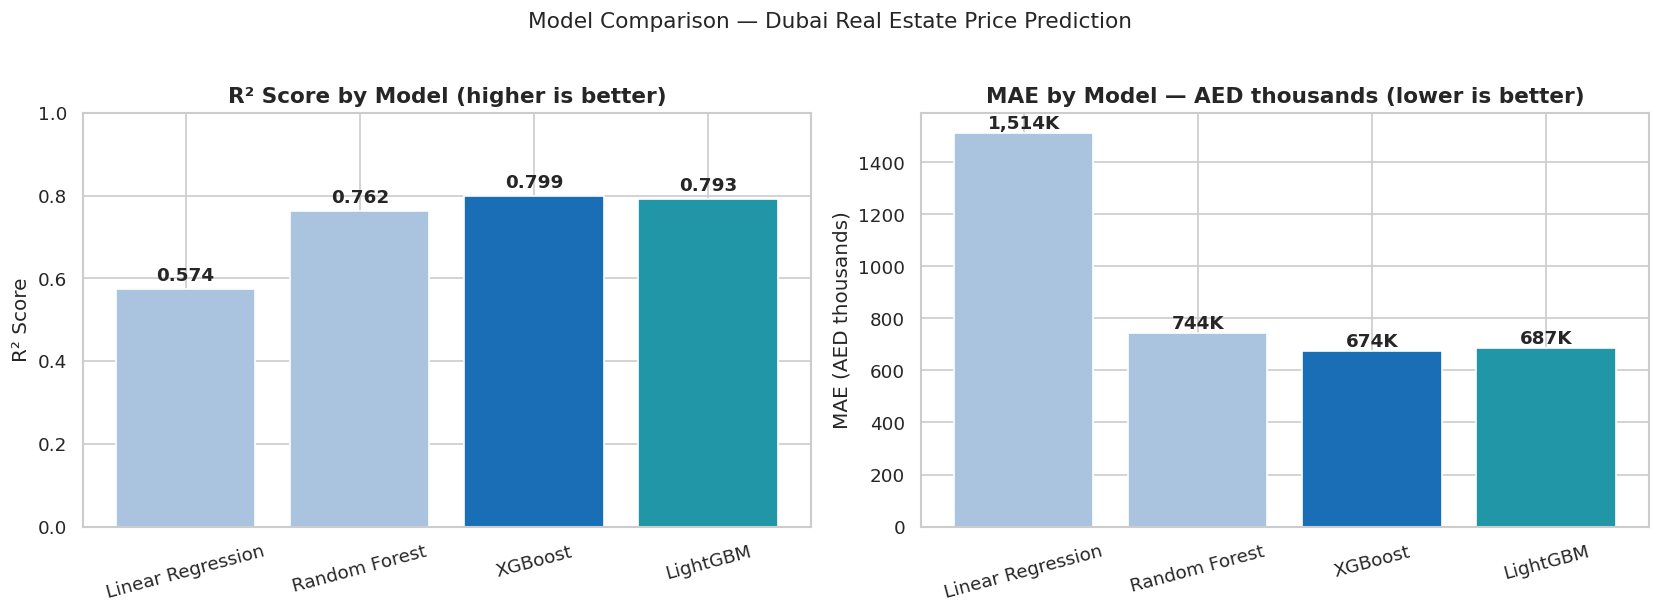

In [27]:
# Visualise model comparison
names = [r['name'] for r in results]
r2_scores = [r['r2'] for r in results]
mae_scores = [r['mae'] / 1000 for r in results]  # in thousands AED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#aac4e0', '#aac4e0', '#1a6eb5', '#2196a6']

# R² comparison
bars = axes[0].bar(names, r2_scores, color=colors, edgecolor='white')
axes[0].set_title('R² Score by Model (higher is better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# MAE comparison
bars2 = axes[1].bar(names, mae_scores, color=colors, edgecolor='white')
axes[1].set_title('MAE by Model — AED thousands (lower is better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAE (AED thousands)')
for bar, val in zip(bars2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:,.0f}K', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — Dubai Real Estate Price Prediction', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

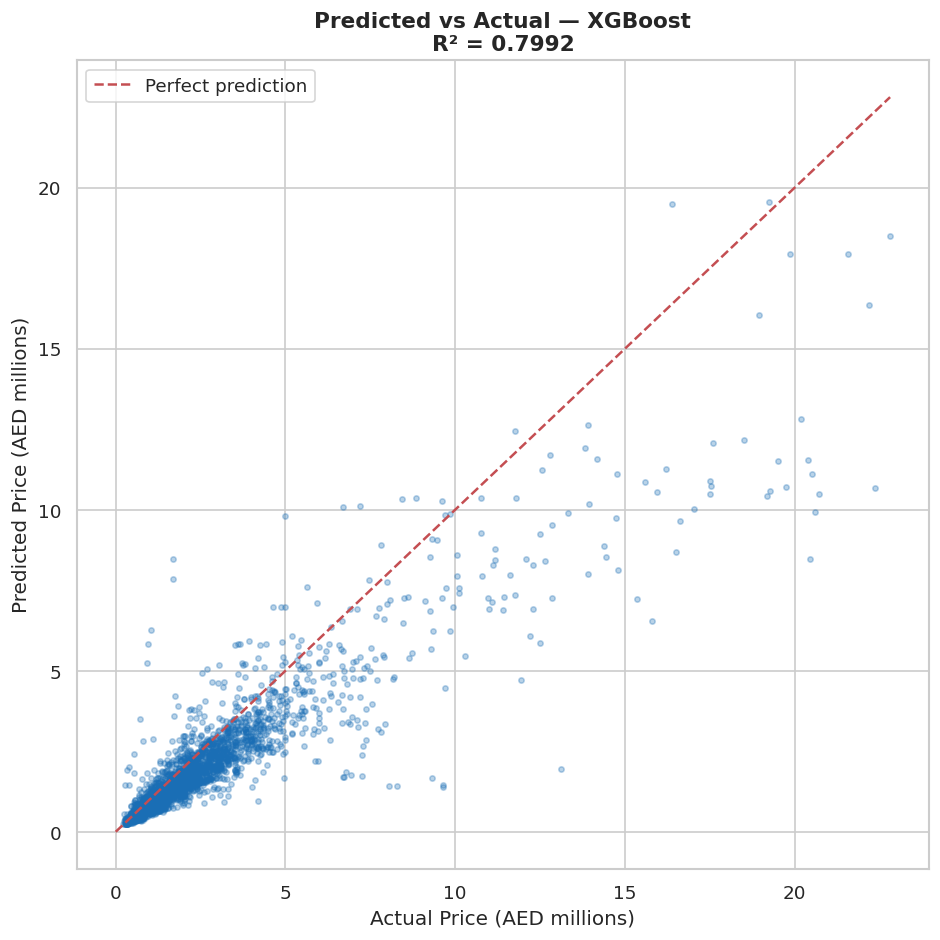

In [28]:
# Predicted vs Actual plot for best model
best_preds = best['preds']
sample_idx = np.random.choice(len(best_preds), size=min(3000, len(best_preds)), replace=False)

actual_sample = y_test_orig.values[sample_idx] / 1e6
pred_sample   = best_preds[sample_idx] / 1e6

plt.figure(figsize=(8, 8))
plt.scatter(actual_sample, pred_sample, alpha=0.3, s=10, color='#1a6eb5')
max_val = max(actual_sample.max(), pred_sample.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Price (AED millions)', fontsize=12)
plt.ylabel('Predicted Price (AED millions)', fontsize=12)
plt.title(f'Predicted vs Actual — {best["name"]}\nR² = {best["r2"]:.4f}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. SHAP Explainability

In [29]:
# Use XGBoost for SHAP (fastest SHAP support)
# If XGBoost wasn't best, we still use it for explainability
print('Calculating SHAP values (this takes ~1 min on large datasets)...')

# Use a sample for SHAP to keep it fast
shap_sample = X_test.sample(min(2000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

print('SHAP values calculated!')

Calculating SHAP values (this takes ~1 min on large datasets)...
SHAP values calculated!


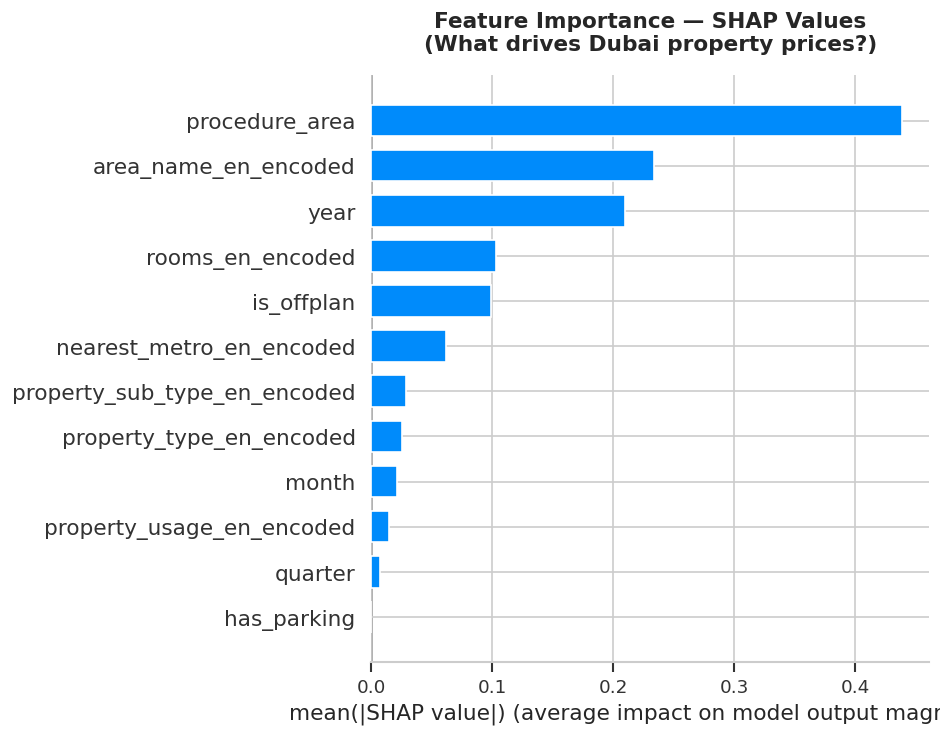

In [30]:
# SHAP Summary Plot — most important features
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_cols,
                  plot_type='bar', show=False)
plt.title('Feature Importance — SHAP Values\n(What drives Dubai property prices?)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()

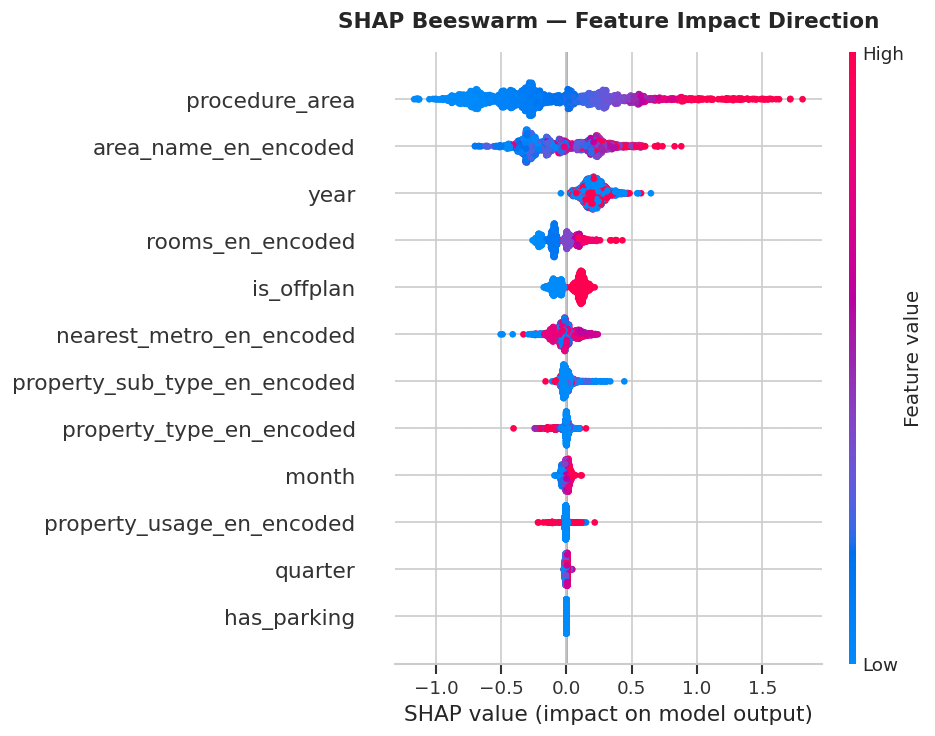


How to read this: Red = high feature value, Blue = low feature value
Points to the right = pushes price UP, left = pushes price DOWN


In [31]:
# SHAP Beeswarm Plot — direction of impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_cols, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nHow to read this: Red = high feature value, Blue = low feature value')
print('Points to the right = pushes price UP, left = pushes price DOWN')

## 7. Save Best Model & Feature List

In [32]:
# Save best model
joblib.dump(best['model'], 'xgboost_model.pkl')
print(f'Saved: xgboost_model.pkl ({best["name"]})')

# Save feature columns list (needed by Streamlit app)
import json
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)
print('Saved: feature_cols.json')

# Save target encoding maps (needed by Streamlit app)
encoding_maps = {}
for col in cat_cols:
    if col in df.columns:
        encoding_maps[col] = df.groupby(col)[target].mean().to_dict()

with open('encoding_maps.json', 'w') as f:
    json.dump(encoding_maps, f)
print('Saved: encoding_maps.json')

# Save area stats for Streamlit dropdowns
area_list = sorted(df['area_name_en'].dropna().unique().tolist())
property_types = sorted(df['property_type_en'].dropna().unique().tolist())

with open('area_list.json', 'w') as f:
    json.dump(area_list, f)
with open('property_types.json', 'w') as f:
    json.dump(property_types, f)

print('Saved: area_list.json, property_types.json')

Saved: xgboost_model.pkl (XGBoost)
Saved: feature_cols.json
Saved: encoding_maps.json
Saved: area_list.json, property_types.json


## 8. Final Summary

In [33]:
print('=' * 65)
print('MODELLING COMPLETE — RESULTS SUMMARY')
print('=' * 65)
print(f'\n Training rows:  {len(X_train):>10,}')
print(f' Test rows:      {len(X_test):>10,}')
print(f' Features used:  {len(feature_cols):>10}')
print()
print(f'{"Model":<25} {"R²":>8} {"MAE (AED)":>15} {"RMSE (AED)":>15}')
print('-' * 65)
for r in results:
    marker = ' ← BEST' if r['name'] == best['name'] else ''
    print(f'{r["name"]:<25} {r["r2"]:>8.4f} {r["mae"]:>15,.0f} {r["rmse"]:>15,.0f}{marker}')
print('=' * 65)
print()
print('Files saved for Streamlit app:')
print('  xgboost_model.pkl   — trained model')
print('  feature_cols.json   — feature list')
print('  encoding_maps.json  — target encodings')
print('  area_list.json      — dropdown values')
print('  property_types.json — dropdown values')
print()
print('Next: Build the Streamlit app using these saved files!')

MODELLING COMPLETE — RESULTS SUMMARY

 Training rows:     835,360
 Test rows:         317,868
 Features used:          12

Model                           R²       MAE (AED)      RMSE (AED)
-----------------------------------------------------------------
Linear Regression           0.5738       1,514,448       9,446,699
Random Forest               0.7625         743,936       1,593,793
XGBoost                     0.7992         674,309       1,440,946 ← BEST
LightGBM                    0.7926         686,944       1,477,968

Files saved for Streamlit app:
  xgboost_model.pkl   — trained model
  feature_cols.json   — feature list
  encoding_maps.json  — target encodings
  area_list.json      — dropdown values
  property_types.json — dropdown values

Next: Build the Streamlit app using these saved files!
